In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
# Load data
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [5]:
train_df.head()


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [6]:
train_df.shape

(198000, 15)

In [7]:
train_df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [9]:
train_df['label'].value_counts()


label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

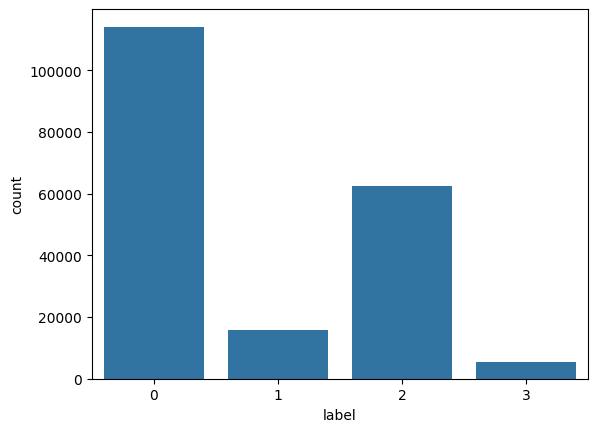

In [10]:
sns.countplot(x='label', data=train_df)
plt.show()


In [11]:
train_df.isnull().sum()


created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [12]:
train_df= train_df.fillna("")


In [13]:
train_df

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,,,,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,,,,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,,,,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,,,,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,,,,False,"Today, the confederate flag...tomorrow, the na...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,,,,False,Why save people who are bent on self-destructi...,0
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,,,,False,Trudeau is not only undemocratic but also innu...,2
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,,,,False,block all exports no humanitarian relief and a...,3
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,none,none,False,really black kids seeing that is better than g...,1


In [14]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import lightgbm as lgb
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

In [15]:
# =========================
# 2. LOAD DATA
# =========================
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
print(train.shape, test.shape)

(198000, 15) (102000, 14)


In [16]:
# =========================
# 3. FEATURE ENGINEERING
# =========================
train["comment"] = train["comment"].fillna("")
test["comment"] = test["comment"].fillna("")

In [17]:
# Text-derived numeric features
for df in [train, test]:
    df["comment_length"] = df["comment"].apply(len)
    df["word_count"] = df["comment"].str.split().str.len().fillna(0)
    df["avg_word_len"] = df["comment_length"] / (df["word_count"] + 1)
    df["excl_count"] = df["comment"].str.count("!")
    df["ques_count"] = df["comment"].str.count(r"\?")
    df["capital_count"] = df["comment"].apply(lambda x: sum(1 for c in x if c.isupper()))
    df["capital_ratio"] = df["capital_count"] / (df["comment_length"] + 1)
    df["unique_word_count"] = df["comment"].apply(lambda x: len(set(x.lower().split())))
    df["unique_word_ratio"] = df["unique_word_count"] / (df["word_count"] + 1)

In [18]:
# Date features
train["created_date"] = pd.to_datetime(train["created_date"], errors="coerce")
test["created_date"] = pd.to_datetime(test["created_date"], errors="coerce")

In [19]:
for df in [train, test]:
    df["hour"] = df["created_date"].dt.hour.fillna(0)
    df["day"] = df["created_date"].dt.day.fillna(0)
    df["dayofweek"] = df["created_date"].dt.dayofweek.fillna(0)

In [20]:
# =========================
# 4. TFIDF TEXT FEATURES
# =========================

In [21]:
# Word-level TF-IDF (improved with sublinear_tf and min_df)
print("Fitting Word TF-IDF...")
word_tfidf = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_text_word = word_tfidf.fit_transform(train["comment"])
X_test_text_word = word_tfidf.transform(test["comment"])
print(f"  Word features: {X_text_word.shape[1]}")

Fitting Word TF-IDF...
  Word features: 25000


In [22]:
# Char-level TF-IDF (NEW - captures subword patterns & misspellings)
print("Fitting Char TF-IDF...")
char_tfidf = TfidfVectorizer(
    max_features=25000,
    analyzer="char_wb",
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_text_char = char_tfidf.fit_transform(train["comment"])
X_test_text_char = char_tfidf.transform(test["comment"])
print(f"  Char features: {X_text_char.shape[1]}")

Fitting Char TF-IDF...
  Char features: 25000


In [23]:
# =========================
# 5. NUMERIC FEATURES
# =========================
num_cols = [
    "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote",
    "if_1", "if_2",
    "race", "religion", "gender", "disability",
    "comment_length", "word_count", "avg_word_len",
    "excl_count", "ques_count", "capital_count", "capital_ratio",
    "unique_word_count", "unique_word_ratio",
    "hour", "day", "dayofweek"
]

In [24]:
X_num = train[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype("float32")
X_test_num = test[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype("float32")

In [25]:
# Combine: Word TF-IDF + Char TF-IDF + Numeric
X = hstack([X_text_word, X_text_char, X_num])
X_test = hstack([X_test_text_word, X_test_text_char, X_test_num])
print(f"Total features: {X.shape[1]}")

Total features: 50023


In [26]:
# =========================
# 6. ENCODE LABEL
# =========================
le = LabelEncoder()
y = le.fit_transform(train["label"])

In [27]:
# =========================
# 7. TRAIN VALIDATION SPLIT
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
# =========================
# 8. MODEL 1 — NAIVE BAYES
# =========================
print("\nTraining MultinomialNB...")
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_val)
print("NB Accuracy:", accuracy_score(y_val, nb_pred))


Training MultinomialNB...
NB Accuracy: 0.5064141414141414


In [29]:
# =========================
# 9. MODEL 2 — LIGHTGBM
# =========================
print("\nTraining LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    is_unbalance=True
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
lgb_pred = lgb_model.predict(X_val)
print("LGB Accuracy:", accuracy_score(y_val, lgb_pred))


Training LightGBM...
LGB Accuracy: 0.9152777777777777


In [30]:
# =========================
# 10. FIND BEST ENSEMBLE WEIGHT
# =========================
print("\nFinding best blend weight...")
nb_prob = nb.predict_proba(X_val)
lgb_prob = lgb_model.predict_proba(X_val)


Finding best blend weight...


In [31]:
best_w, best_acc = 0.5, 0
for w in np.arange(0.1, 0.9, 0.05):
    blended = w * nb_prob + (1 - w) * lgb_prob
    pred = np.argmax(blended, axis=1)
    acc = accuracy_score(y_val, pred)
    if acc > best_acc:
        best_acc = acc
        best_w = w

In [32]:
print(f"Best weight: NB={best_w:.2f}, LGB={1-best_w:.2f}")
print(f"Ensemble Accuracy: {best_acc:.4f}")

Best weight: NB=0.10, LGB=0.90
Ensemble Accuracy: 0.9162


In [33]:
# Also check the 50/50 blend
blend_50 = 0.5 * nb_prob + 0.5 * lgb_prob
print(f"50/50 Accuracy: {accuracy_score(y_val, np.argmax(blend_50, axis=1)):.4f}")

50/50 Accuracy: 0.6566


In [34]:
# =========================
# 11. TRAIN FULL MODEL
# =========================
print("\nRetraining on full data...")
nb.fit(X, y)
lgb_model_full = lgb.LGBMClassifier(
    n_estimators=lgb_model.best_iteration_ if hasattr(lgb_model, 'best_iteration_') else 300,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    is_unbalance=True
)
lgb_model_full.fit(X, y)


Retraining on full data...


LGBMClassifier(colsample_bytree=0.8, is_unbalance=True, learning_rate=0.05,
               max_depth=8, min_child_samples=30, n_estimators=500, n_jobs=-1,
               num_leaves=64, random_state=42, reg_alpha=0.1, reg_lambda=0.1,
               subsample=0.8, verbose=-1)

In [35]:
# =========================
# 12. TEST PREDICTION
# =========================
print("Predicting on test data...")
nb_test = nb.predict_proba(X_test)
lgb_test = lgb_model_full.predict_proba(X_test)

Predicting on test data...


In [36]:
# Use the best weight found
final_test = best_w * nb_test + (1 - best_w) * lgb_test
pred = np.argmax(final_test, axis=1)
pred = le.inverse_transform(pred)

In [37]:
# =========================
# 13. SUBMISSION FILE
# =========================
sample["label"] = pred
sample.to_csv("submission.csv", index=False)
print(f"\nSubmission created! Distribution: {pd.Series(pred).value_counts().sort_index().to_dict()}")
print(f"Best blend weight: NB={best_w:.2f}, LGB={1-best_w:.2f}")
print(f"Val accuracy: {best_acc:.4f}")



Submission created! Distribution: {0: 56933, 1: 7866, 2: 35268, 3: 1933}
Best blend weight: NB=0.10, LGB=0.90
Val accuracy: 0.9162
